In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
IMG_SIZE = 28
MB_SIZE = 96
REMOVE = [9, 25]  # J and Z
RANDOM_STATE = 42

# Correct SignMNIST letter order (after removing J and Z)
CLASS_NAMES = [
    'A','B','C','D','E','F','G','H','I',
    'K','L','M','N','O','P','Q','R','S',
    'T','U','V','W','X','Y'
]

In [ ]:
#Load Datasets
train_df = pd.read_csv("/content/drive/MyDrive/datasets/sign_mnist_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/datasets/sign_mnist_test.csv")

X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

print(train_df.shape, test_df.shape)

(27455, 785) (7172, 785)


In [ ]:
train_mask = ~np.isin(y_train, REMOVE)
test_mask  = ~np.isin(y_test, REMOVE)

X_train, y_train = X_train[train_mask], y_train[train_mask]
X_test,  y_test  = X_test[test_mask],  y_test[test_mask]

In [ ]:
unique_labels = sorted(np.unique(y_train))
label_map = {old: new for new, old in enumerate(unique_labels)}

y_train = np.array([label_map[y] for y in y_train])
y_test  = np.array([label_map[y] for y in y_test])

NUM_CLASSES = len(unique_labels)
print("Number of classes:", NUM_CLASSES)

np.save("class_names.npy", np.array(CLASS_NAMES))

Number of classes: 24


In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32")
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=RANDOM_STATE
)

In [ ]:
#CNN data normalised
X_tr_cnn  = X_tr / 255.0
X_val_cnn = X_val / 255.0

#mobilenet data (raw)
X_tr_mb  = X_tr
X_val_mb = X_val

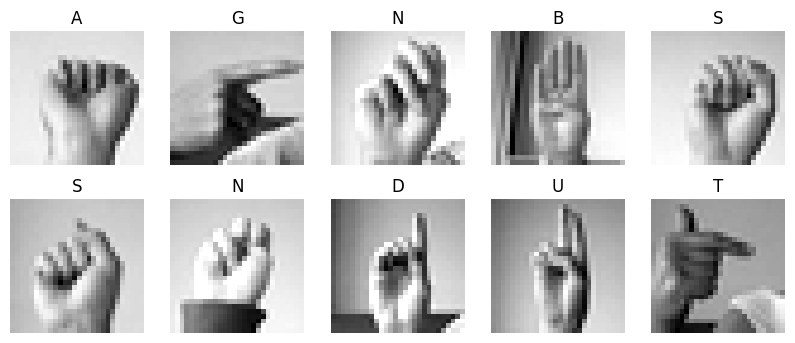

In [ ]:
plt.figure(figsize=(10,4))

for i in range(10):
    idx = np.random.randint(len(X_tr))
    plt.subplot(2,5,i+1)
    plt.imshow(X_tr[idx].squeeze(), cmap="gray")
    plt.title(CLASS_NAMES[y_tr[idx]])
    plt.axis("off")

plt.show()


In [ ]:
def build_cnn(num_classes):
    inputs = keras.Input(shape=(28,28,1))

    x = layers.Conv2D(32, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

MB_SIZE = 96

def preprocess_for_mobilenet(X):
    X = tf.convert_to_tensor(X, dtype=tf.float32)

    # Resize 28x28 → 96x96
    X = tf.image.resize(X, (MB_SIZE, MB_SIZE))

    # Convert grayscale → RGB
    X = tf.image.grayscale_to_rgb(X)

    # Apply MobileNet preprocessing
    X = preprocess_input(X)

    return X

In [ ]:
def build_mobilenet(num_classes):

    base = applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(96, 96, 3)
    )

    base.trainable = False

    inputs = keras.Input(shape=(96,96,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [ ]:
#Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-5
    )
]

In [ ]:
#Train CNN
cnn = build_cnn(NUM_CLASSES)
history_cnn = cnn.fit(
    X_tr_cnn, y_tr,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.1701 - loss: 2.7119 - val_accuracy: 0.0910 - val_loss: 5.5473 - learning_rate: 0.0010
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6607 - loss: 0.9537 - val_accuracy: 0.6366 - val_loss: 0.8971 - learning_rate: 0.0010
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8498 - loss: 0.4313 - val_accuracy: 0.1682 - val_loss: 11.4566 - learning_rate: 0.0010
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9146 - loss: 0.2812 - val_accuracy: 0.7757 - val_loss: 0.7737 - learning_rate: 0.0010
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9602 - loss: 0.1321 - val_accuracy: 0.8729 - val_loss: 0.3855 - learning_rate: 0.0010
Epoch 6/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9715 - loss: 0.0952 - val_accuracy: 0.8500 - val_loss: 0.3846 - learning_rate: 0.0010
Epoch 7/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.0680

In [ ]:
X_tr_mb  = preprocess_for_mobilenet(X_tr)
X_val_mb = preprocess_for_mobilenet(X_val)

print(X_tr_mb.shape)  # (N, 96, 96, 3)

#train mobilenet model
mobilenet = build_mobilenet(NUM_CLASSES)
history_mb = mobilenet.fit(
    X_tr_mb, y_tr,
    validation_data=(X_val_mb, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

(24709, 96, 96, 3)
Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 81ms/step - accuracy: 0.3541 - loss: 2.3546 - val_accuracy: 0.9304 - val_loss: 0.4931 - learning_rate: 1.0000e-04
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8517 - loss: 0.5619 - val_accuracy: 0.9818 - val_loss: 0.1899 - learning_rate: 1.0000e-04
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9383 - loss: 0.2776 - val_accuracy: 0.9909 - val_loss: 0.1022 - learning_rate: 1.0000e-04
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9656 - loss: 0.1752 - val_accuracy: 0.9949 - val_loss: 0.0638 - learning_rate: 1.0000e-04
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9788 - loss: 0.1189 - val_accuracy: 0.9960 - val_loss: 0.0444 - learning_rate: 1.0000e-04
Epoch 6/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9867 - loss: 0.0863 - val_accuracy: 0.9971 - val_loss: 0.0333 - learning_rate: 1.0000e-04
Epoch 7/15
387/387 ━━━━━━━━━━━━━━━━━━━

In [ ]:
#save models
cnn.save("cnn_model.keras")
mobilenet.save("mobilenet_model.keras")

print("Training complete. Models saved.")

Training complete. Models saved.


In [ ]:
def compare_histories(history_cnn, history_mb, labels=("CNN", "MobileNet")):
    epochs_cnn = range(1, len(history_cnn.history["accuracy"]) + 1)
    epochs_mb  = range(1, len(history_mb.history["accuracy"]) + 1)

    plt.figure(figsize=(14,8))

    # -------- Accuracy --------
    plt.subplot(2,1,1)
    plt.plot(epochs_cnn, history_cnn.history["accuracy"],
             label=f"{labels[0]} Train", linewidth=2)
    plt.plot(epochs_cnn, history_cnn.history["val_accuracy"],
             label=f"{labels[0]} Val", linestyle="--", linewidth=2)

    plt.plot(epochs_mb, history_mb.history["accuracy"],
             label=f"{labels[1]} Train", linewidth=2)
    plt.plot(epochs_mb, history_mb.history["val_accuracy"],
             label=f"{labels[1]} Val", linestyle="--", linewidth=2)

    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)

    # -------- Loss --------
    plt.subplot(2,1,2)
    plt.plot(epochs_cnn, history_cnn.history["loss"],
             label=f"{labels[0]} Train", linewidth=2)
    plt.plot(epochs_cnn, history_cnn.history["val_loss"],
             label=f"{labels[0]} Val", linestyle="--", linewidth=2)

    plt.plot(epochs_mb, history_mb.history["loss"],
             label=f"{labels[1]} Train", linewidth=2)
    plt.plot(epochs_mb, history_mb.history["val_loss"],
             label=f"{labels[1]} Val", linestyle="--", linewidth=2)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss Comparison")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

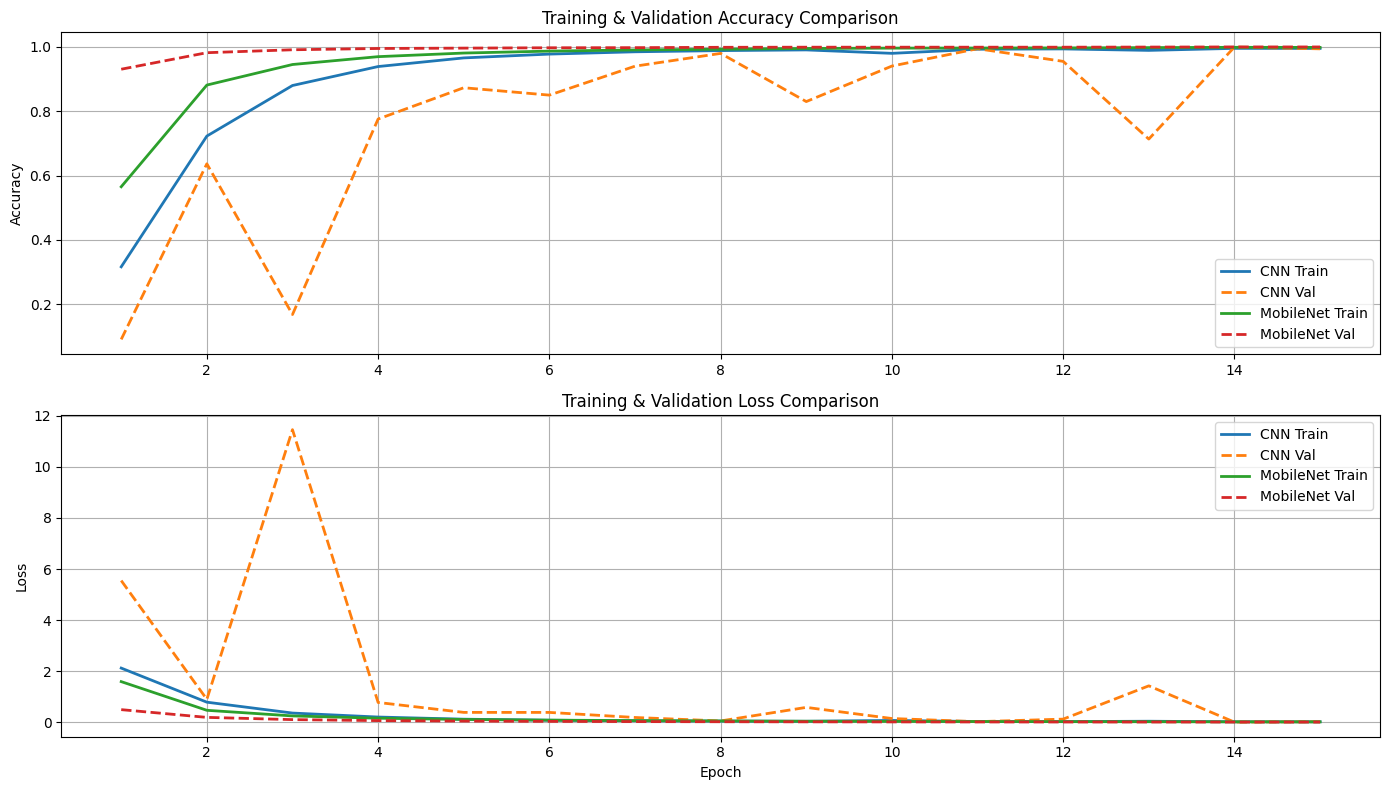

In [ ]:
compare_histories(history_cnn, history_mb)

In [ ]:
#Evaluate Models
target_names = CLASS_NAMES

print("CNN:")
print(classification_report(
    y_test,
    np.argmax(cnn.predict(X_test), axis=1),
    target_names=target_names
))

X_test_mb = preprocess_for_mobilenet(X_test)

mobilenet.predict(X_test_mb)

print("MobileNet:")
print(classification_report(
    y_test,
    np.argmax(mobilenet.predict(X_test_mb), axis=1),
    target_names=target_names
))


CNN:
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           A       0.87      0.33      0.48       331
           B       0.74      0.52      0.61       432
           C       0.40      0.93      0.56       310
           D       1.00      0.30      0.46       245
           E       0.88      0.26      0.40       498
           F       0.99      0.64      0.78       247
           G       1.00      0.05      0.09       348
           H       1.00      0.50      0.66       436
           I       0.52      0.24      0.32       288
           K       0.87      0.39      0.54       331
           L       1.00      0.19      0.31       209
           M       0.94      0.43      0.59       394
           N       1.00      0.04      0.09       291
           O       0.15      1.00      0.26       246
           P       1.00      0.30      0.46       347
           Q       0.22      0.99      0.37       164
           R       0.49      0.25  